# Język Python w Analizie Danych
# Wstęp do uczenia maszynowego

## Cel zajęć

- Zrozumienie podstawowych pojęć uczenia maszynowego
- Praca z biblioteką `scikit-learn`
- implementacja i ewaluacja modeli klasyfikacji oraz regresji

## Część teoretyczna

### Dokumentacja
- Scikit-learn: https://scikit-learn.org/stable/user_guide.html
- Pytorch: https://docs.pytorch.org/docs/stable/index.html
- Tensorflow: https://www.tensorflow.org/learn?hl=pl

In [1]:
# Instalacja modułów
#!pip install -U scikit-learn
#!choco install pytorch
#!pip install tensorflow

!pip install numpy pandas seaborn matplotlib


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
# Import niezbędnych bibliotek
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Import modułów sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Przykłady

#### Klasyfikacja

In [2]:
# Wczytanie i przygotowanie danych (predefiniowany dataset)
from sklearn import datasets
iris = datasets.load_iris()
x = iris.data
y = iris.target
target_names = iris.target_names

In [18]:
# Podział na dane testowe i treningowe

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Shape: {X_test.shape}")
print(f"Data: {X_test}")

Shape: (45, 4)
Data: [[7.3 2.9 6.3 1.8]
 [6.1 2.9 4.7 1.4]
 [6.3 2.8 5.1 1.5]
 [6.3 3.3 4.7 1.6]
 [6.1 3.  4.9 1.8]
 [6.7 3.1 5.6 2.4]
 [5.5 2.3 4.  1.3]
 [5.6 2.5 3.9 1.1]
 [5.4 3.4 1.7 0.2]
 [6.9 3.1 5.1 2.3]
 [5.8 4.  1.2 0.2]
 [4.4 3.  1.3 0.2]
 [6.7 2.5 5.8 1.8]
 [6.5 3.  5.5 1.8]
 [5.2 3.4 1.4 0.2]
 [6.2 3.4 5.4 2.3]
 [4.9 2.4 3.3 1. ]
 [5.4 3.7 1.5 0.2]
 [5.1 3.3 1.7 0.5]
 [5.7 3.8 1.7 0.3]
 [6.2 2.9 4.3 1.3]
 [5.  3.4 1.5 0.2]
 [6.6 3.  4.4 1.4]
 [6.5 3.  5.8 2.2]
 [6.  3.  4.8 1.8]
 [6.4 3.2 4.5 1.5]
 [5.4 3.  4.5 1.5]
 [5.  2.3 3.3 1. ]
 [5.6 3.  4.5 1.5]
 [5.  3.2 1.2 0.2]
 [6.1 2.6 5.6 1.4]
 [6.4 2.8 5.6 2.2]
 [6.  3.4 4.5 1.6]
 [5.  3.3 1.4 0.2]
 [6.4 2.7 5.3 1.9]
 [5.  3.5 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [4.7 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [6.7 3.  5.  1.7]
 [5.7 2.8 4.5 1.3]
 [4.6 3.6 1.  0.2]
 [4.9 2.5 4.5 1.7]
 [6.5 3.  5.2 2. ]
 [6.6 2.9 4.6 1.3]]


In [19]:
# Skalowanie danych (jeśli kluczowe dla algorytmu)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Shape: {X_test_scaled.shape}")
print(f"Data: {X_test_scaled}")

Shape: (45, 4)
Data: [[ 1.66119088 -0.34116698  1.41660741  0.76797223]
 [ 0.26392752 -0.34116698  0.51547131  0.25106784]
 [ 0.49680475 -0.56093712  0.74075533  0.38029394]
 [ 0.49680475  0.53791358  0.51547131  0.50952003]
 [ 0.26392752 -0.12139684  0.62811332  0.76797223]
 [ 0.9625592   0.0983733   1.02236036  1.5433288 ]
 [-0.43470415 -1.65978782  0.12122426  0.12184175]
 [-0.31826554 -1.22024754  0.06490325 -0.13661044]
 [-0.55114277  0.75768372 -1.17415888 -1.29964531]
 [ 1.19543642  0.0983733   0.74075533  1.41410271]
 [-0.08538832  2.07630456 -1.45576392 -1.29964531]
 [-1.7155289  -0.12139684 -1.39944291 -1.29964531]
 [ 0.9625592  -1.22024754  1.13500238  0.76797223]
 [ 0.72968197 -0.12139684  0.96603936  0.76797223]
 [-0.78401999  0.75768372 -1.3431219  -1.29964531]
 [ 0.38036614  0.75768372  0.90971835  1.41410271]
 [-1.13333583 -1.44001768 -0.27302278 -0.26583654]
 [-0.55114277  1.41699414 -1.2868009  -1.29964531]
 [-0.90045861  0.53791358 -1.17415888 -0.91196702]
 [-0.20182

In [20]:
# Inicjalizacja i trenowanie modelu
svm_model = SVC(kernel='linear', C=1.0, random_state=42)
svm_model.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [21]:
# Predykcja na zbiorze testowym
y_pred = svm_model.predict(X_test_scaled)

In [22]:
# Ewaluacja
print(f"Dokładność modelu (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print("\nRaport klasyfikacji:\n")
print(classification_report(y_test, y_pred, target_names=target_names))

Dokładność modelu (Accuracy): 0.9111

Raport klasyfikacji:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



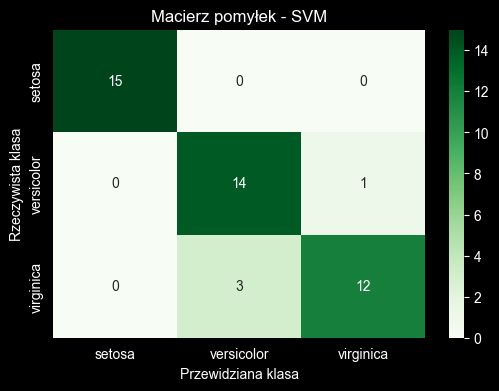

In [23]:
# Wizualizacja macierzy błędów
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=target_names, yticklabels=target_names)
plt.title("Macierz pomyłek - SVM")
plt.ylabel("Rzeczywista klasa")
plt.xlabel("Przewidziana klasa")
plt.show()

#### Regresja

In [3]:
# Wczytanie i przygotowanie danych (predefiniowany dataset)
data = datasets.fetch_california_housing()
x = data.data
y = data.target
feature_names = data.feature_names

print(f"Liczba próbek: {x.shape[0]}, Liczba cech: {x.shape[1]}")

Liczba próbek: 20640, Liczba cech: 8


In [7]:
# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [8]:
# Skalowanie danych (Standaryzacja)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# Inicjalizacja i trening modelu SVR
svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_model.fit(X_train_scaled, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [10]:
# Predykcja na danych testowych
y_pred = svr_model.predict(X_test_scaled)

In [11]:
# Ewaluacja modelu
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Wyniki ewaluacji SVR ---")
print(f"MAE (Mean Absolute Error): {mae:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"R^2 (Współczynnik determinacji): {r2:.4f}")


--- Wyniki ewaluacji SVR ---
MAE (Mean Absolute Error): 0.3986
RMSE (Root Mean Squared Error): 0.5975
R^2 (Współczynnik determinacji): 0.7276


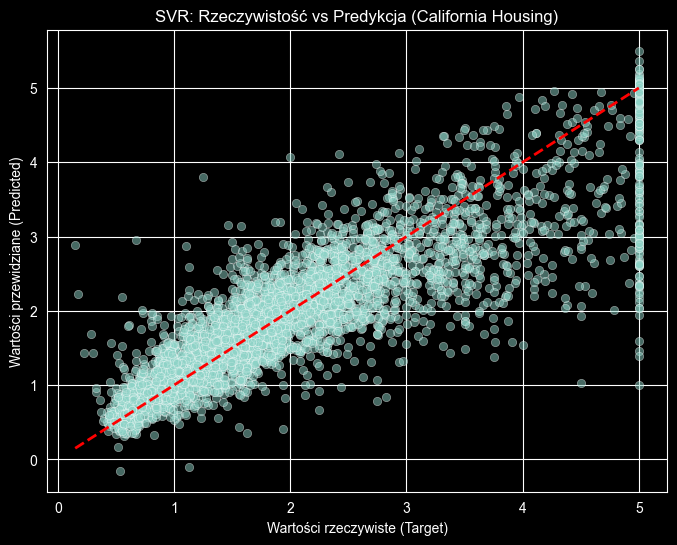

In [12]:
# Wizualizacja
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Wartości rzeczywiste (Target)")
plt.ylabel("Wartości przewidziane (Predicted)")
plt.title("SVR: Rzeczywistość vs Predykcja (California Housing)")
plt.grid(True)
plt.show()

### Zadanie 1
Wczytaj dane z pliku `data06_classification.csv` do `pandas.DataFrame`. Przeprowadź wstępną analizę (sprawdź braki danych, typy zmiennych). Jeśli to konieczne, uzupełnij braki lub usuń uszkodzone rekordy.

In [26]:
# TODO: EDA

Zdefiniuj zmienną celu (y) oraz cechy (X). W przypadku zmiennych tekstowych (np. 'sex'), zamień je na wartości liczbowe.

In [ ]:
# TODO:
x, y = None

Podziel zbiór na treningowy i testowy w odpowiednich proporcjach.

In [ ]:
# TODO:
X_train, X_test, y_train, y_test = None

Wytrenuj model `RandomForestClassifier` i dokonaj predykcji na zbiorze testowym.

In [ ]:
# TODO:
# trening

# predykcja

Wyświetl raport klasyfikacji (classification_report) oraz macierz pomyłek (confusion_matrix). Przeanalizuj, które cechy były najważniejsze dla modelu (atrybut feature_importances_).

In [ ]:
# TODO:
print("Macierz pomyłek: \n")

print("Raport klasyfikacji:\n")

print("Cechy:\n")

### Zadanie 2
Wczytaj i przygotuj dane z pliku `data06_regression.csv` (analogicznie do Zadania 1). Zmienną celu będzie kolumna numeryczna `PerformanceIndex`.

In [ ]:
# TODO: EDA + data preparation

Podziel dane na zbiór treningowy i testowy. Zastosuj skalowanie danych przy pomocy `StandardScaler`.

In [ ]:
# TODO:
X_train, X_test, y_train, y_test = None

Dobierz hiperparametry modeli `MLPRegressor`. Wytrenuj modele i dokonaj predykcji na zbiorze testowym. Porównaj wyniki modeli z modelem o domyślnych hiperparametrach.

In [ ]:
# TODO:
model1 = MLPRegressor(
    # TODO: uzupełnij wartości None
    hidden_layer_sizes=(None, None),
    activation=None,
    solver=None,
    max_iter=None,
    random_state=None
)
model2 = MLPRegressor(
    # TODO: podaj wybrane parametry (mogą być inne niż w modelu1)
)
model_default = MLPRegressor()
# trening

# predykcja

Wyznacz i wyświetl następujące miary jakości modelu:
- MAE (Mean Absolute Error) – Średni błąd bezwzględny.
- MSE (Mean Squared Error) – Błąd średniokwadratowy.
- RMSE (Root Mean Squared Error) – Pierwiastek błędu średniokwadratowego.
- R2 (Współczynnik determinacji).

In [ ]:
# TODO:
mae = None
mse = None
rmse = None
r2 = None

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R^2: {r2:.2f}")

Zwizualizuj efekt działania regresji.

In [ ]:
# TODO:
print("MLPRegressor: Rzeczywistość vs Predykcja")